# SSH 사슬의 갭 안 상태 — 에지 상태의 정체와 유지 조건

전산물리학 기말 프로젝트 · 신효산

## 물리 질문 (하나)
> $t_2>t_1$일 때 SSH 사슬의 갭 안에 생기는 상태는 무엇이고, 어떤 조건에서 유지되는가?

(중간 프로젝트의 예비 관찰: 끝이 있는 사슬의 갭 안에 $E\approx0$ 상태가 2개 있다. 이 노트북은 그 원인과 유지 조건을 다룬다.)

## 계산할 양
- 상태의 진폭 분포와 국소화 길이, 첫 사이트 확률
- 영 근처 에너지 $\min\lvert E\rvert$의 사슬 길이 의존성 (1차 섭동 공식과 비교)
- 카이랄 대칭의 수치 확인: $\Sigma H\Sigma+H$, 고유값 $\pm E$ 쌍
- 난수 무질서(hopping, 온사이트)에서의 영 근처 에너지: 평균 ± 표준오차, 표본 수 $M$ 의존성
- 회전수 (Zak phase는 계산만 하고 이론은 인용)

## 모델, 가정, 경계조건
| 항목 | 내용 |
|---|---|
| 모델 | SSH 사슬: 단위셀에 A, B 두 원자, 셀 안 hopping $t_1$, 셀 사이 hopping $t_2$, 셀 수 $N_c$ |
| 가정 | 최근접 hopping만, 오비탈 직교, 온사이트 에너지 없음 (hopping은 항상 A–B 사이) |
| 경계조건 | **열린** (유한 사슬), 회전수는 주기 |
| 규약 | A 원자에서 시작하고 첫 결합이 $t_1$ |

## 수치 방법과 선택 이유
| 방법 | 이유 |
|---|---|
| $2N_c\times2N_c$ 실공간 행렬 대각화 | 끝이 있어 Bloch 정리를 쓸 수 없다. 작아서 정확하고 수렴 변수가 없다 |
| 고유벡터로 진폭 분포 | 상태의 위치와 감쇠를 직접 본다 |
| 난수 무질서 $M$개 | 평균과 표준오차로 결론이 표본에 좌우되는지 확인 |

## 입력과 출력
- 입력: `input/params.json` (없으면 기본값으로 만든다). 난수 시드도 여기에 있다
- 출력: `output/*.csv`, `output/summary.json`, `output/figs/*.png`

각 절은 **예측 → 실행 → 확인** 순서다.

## 0. 설정: 입력 파일 읽기와 출력 준비

In [1]:
import csv, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DEFAULT_PARAMS = {
    "ssh_pairs": [[1.0, 0.5], [0.5, 1.0]],
    "chain": {"n_cells": 20, "edge_threshold": 0.1, "amp_n_cells": 30},
    "localization": {"r_list": [0.0, 0.5, 0.8, 0.95], "n_cells": 60},
    "resolution": {"ncell_list": [4, 6, 8, 10, 12, 16, 20, 30, 40], "ncell_pairs": [[0.5, 1.0], [0.8, 1.0]], "fit_min_ncell": 12},
    "chiral": {"strength": 0.3, "n_realizations": 40, "seed": 777},
    "winding_pairs": [[1.0, 0.5], [0.5, 1.0], [2.0, 1.0], [1.0, 3.0]],
    "zak_k_points": 400,
    "zak_scan": {"t1": 1.0, "t2_min": 0.05, "t2_max": 2.0, "n": 40},
    "disorder": {
        "n_cells": 20, "t1": 0.5, "t2": 1.0,
        "strengths": [0.0, 0.1, 0.2, 0.3, 0.4],
        "n_realizations": 40,
        "M_list": [5, 10, 20, 40, 80, 160], "M_strength": 0.3,
        "seed": 12345
    }
}

import re
def compact_json(obj):
    # 숫자 리스트를 한 줄로 접어서 입력 파일을 읽기 쉽게 쓴다
    text = json.dumps(obj, indent=2)
    pat = re.compile(r"\[\s*([^\[\]{}]*?)\s*\]")
    prev = None
    while prev != text:
        prev = text
        text = pat.sub(lambda m: "[" + re.sub(r"\s+", " ", m.group(1)) + "]", text)
    return text

PARAMS_PATH = Path("input/params.json")
if not PARAMS_PATH.exists():
    PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    PARAMS_PATH.write_text(compact_json(DEFAULT_PARAMS))
    print("input/params.json 이 없어서 기본값으로 만들었다.")
P = json.loads(PARAMS_PATH.read_text())
print("입력 파일:", PARAMS_PATH.resolve())

OUT = Path("output"); FIGS = OUT / "figs"; FIGS.mkdir(parents=True, exist_ok=True)
SUMMARY = {}                                     # 핵심 수치 모음 -> output/summary.json

def save_csv(name, header, rows):
    with open(OUT / name, "w", newline="") as f:
        w = csv.writer(f); w.writerow(header); w.writerows(rows)

def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

A_LATTICE = 1.0
plt.rcParams["figure.dpi"] = 110
pairs = [tuple(p) for p in P["ssh_pairs"]]          # 비교할 (t1, t2) 쌍

input/params.json 이 없어서 기본값으로 만들었다.
입력 파일: /home/claude/nbfinal/run/input/params.json


## 1. 갭 안 상태의 존재: 스펙트럼과 위치

끝이 있는 사슬을 실공간 행렬로 만들어 대각화한다 (열린 경계조건, A 원자에서 시작, 첫 결합 $t_1$).

**예측**: 어느 사슬에서 $E\approx0$ 상태가 나타나는가? 몇 개이고 어디에 있는가?

trivial (nu=0): E=0 근처 상태 0개, 가장 가까운 두 에너지 = [ 0.5101 -0.5101]
non-trivial (nu=1): E=0 근처 상태 2개, 가장 가까운 두 에너지 = [-0.  0.]


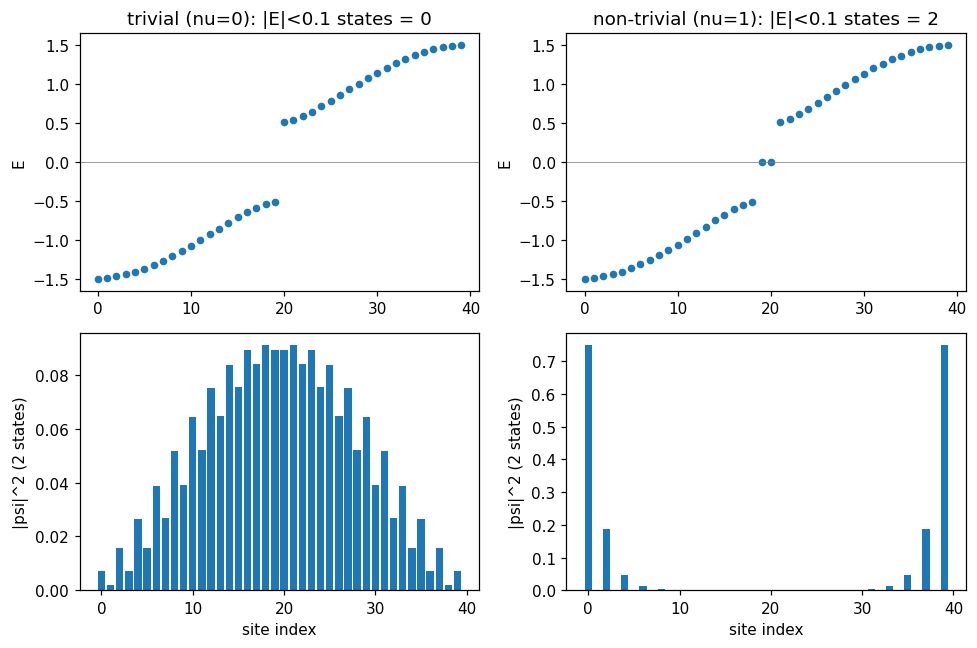

In [2]:
def finite_ssh(n_cells, t1, t2):
    n = 2 * n_cells
    H = np.zeros((n, n))
    for c in range(n_cells):
        H[2*c, 2*c+1] = H[2*c+1, 2*c] = t1          # 셀 안: A_c - B_c
    for c in range(n_cells - 1):
        H[2*c+1, 2*c+2] = H[2*c+2, 2*c+1] = t2      # 셀 간: B_c - A_{c+1}
    return H

N_CELLS = P["chain"]["n_cells"]; THR = P["chain"]["edge_threshold"]
fig, ax = plt.subplots(2, len(pairs), figsize=(4.5 * len(pairs), 6))
edge_cols, edge_head, dens_cols = [], ["index"], []
edge_counts = {}
for col, (t1, t2) in enumerate(pairs):
    name = "non-trivial (nu=1)" if t2 > t1 else "trivial (nu=0)"
    E, V = np.linalg.eigh(finite_ssh(N_CELLS, t1, t2))
    n_zero = int(np.sum(np.abs(E) < THR)); edge_counts[name] = n_zero
    ax[0, col].plot(E, "o", ms=4); ax[0, col].axhline(0, color="gray", lw=0.5)
    ax[0, col].set_title(f"{name}: |E|<{THR} states = {n_zero}"); ax[0, col].set_ylabel("E")
    idx = np.argsort(np.abs(E))[:2]                  # E=0에 가장 가까운 상태 2개
    dens = np.sum(np.abs(V[:, idx])**2, axis=1)
    ax[1, col].bar(range(len(dens)), dens)
    ax[1, col].set_xlabel("site index"); ax[1, col].set_ylabel("|psi|^2 (2 states)")
    print(f"{name}: E=0 근처 상태 {n_zero}개, 가장 가까운 두 에너지 = {np.round(E[idx], 5)}")
    edge_cols.append(E.tolist()); edge_head.append(f"E(t1={t1},t2={t2})"); dens_cols.append(dens.tolist())
plt.tight_layout(); save_fig("fig6_edge_states"); plt.show()
save_csv("edge_states.csv", edge_head, [[i] + [c[i] for c in edge_cols] for i in range(2 * N_CELLS)])
save_csv("edge_density.csv", ["site"] + [f"density(t1={a},t2={b})" for a, b in pairs], [[i] + [c[i] for c in dens_cols] for i in range(2 * N_CELLS)])
SUMMARY["edge_state_count"] = edge_counts

**확인**
- $t_1>t_2$: $\lvert E\rvert<0.1$ 상태 **0개**, 가장 가까운 에너지 $\pm0.51$
- $t_2>t_1$: **2개**, 확률이 사슬 **양 끝**에 집중
- 두 상태의 에너지는 부호만 다른 쌍($\pm\epsilon$)으로 나온다 (3절에서 크기를, 4절에서 이유를 본다)

## 2. 상태의 진폭, 존재 조건, 국소화 길이 (이론 E1~E6)

$E=0$이고 A 원자에만 진폭이 있는 해를 찾으면 B 사이트의 방정식에서 $t_1\psi_{A,n}+t_2\psi_{A,n+1}=0$이 되어

$$
\psi_{A,n}=\left(-\frac{t_1}{t_2}\right)^{n-1}\psi_{A,1},\qquad \lvert\psi_{A,1}\rvert^2=1-\left(\frac{t_1}{t_2}\right)^2,\qquad \xi=\frac{1}{\ln(t_2/t_1)}
$$

규격화 조건이 $\lvert t_1/t_2\rvert<1$, 즉 $t_2>t_1$이다. 오른쪽 끝의 상태는 B 원자에만 진폭이 있고 같은 비율로 안쪽으로 줄어든다.

**예측**: 이웃 셀 진폭비, 첫 사이트 확률은 얼마인가?

수치로 얻은 인접 A사이트 진폭비: [0.5 0.5 0.5 0.5 0.5]
이론 t1/t2                    : 0.5


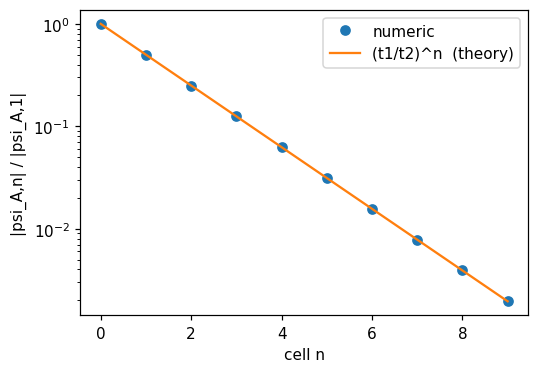

In [3]:
# 이론 예측 |psi_A,n| ∝ (t1/t2)^(n-1) 과 수치 결과 비교 (왼쪽 끝 에지 상태)
t1, t2 = [p for p in pairs if p[1] > p[0]][0]
E, V = np.linalg.eigh(finite_ssh(P["chain"]["amp_n_cells"], t1, t2))
i0, i1 = np.argsort(np.abs(E))[:2]
# 두 영모드의 합/차로 왼쪽·오른쪽 끝 상태를 분리
left = V[:, i0] + V[:, i1]; left /= np.linalg.norm(left)
if abs(left[0]) < abs(left[-1]):
    left = V[:, i0] - V[:, i1]; left /= np.linalg.norm(left)
amp_A = np.abs(left[0::2])                      # A 사이트 진폭
n = np.arange(10)
ratio_num = amp_A[1:10] / amp_A[0:9]
print("수치로 얻은 인접 A사이트 진폭비:", np.round(ratio_num[:5], 4))
print("이론 t1/t2                    :", t1 / t2)
SUMMARY["edge_amp_ratio_numeric"] = float(ratio_num[0]); SUMMARY["edge_amp_ratio_theory"] = t1 / t2
save_csv("edge_amplitude.csv", ["n", "amp_over_amp0_numeric", "theory_(t1/t2)^n"], zip(n.tolist(), (amp_A[:10] / amp_A[0]).tolist(), ((t1 / t2) ** n).tolist()))

plt.figure(figsize=(5, 3.5))
plt.semilogy(n, amp_A[:10] / amp_A[0], "o", label="numeric")
plt.semilogy(n, (t1 / t2) ** n, "-", label="(t1/t2)^n  (theory)")
plt.xlabel("cell n"); plt.ylabel("|psi_A,n| / |psi_A,1|"); plt.legend()
plt.tight_layout(); save_fig("fig7_edge_decay"); plt.show()

In [4]:
# r = t1/t2 를 바꿔 가며: 왼쪽 끝 상태의 첫 사이트 확률, 감쇠율, 반대 부격자 가중치 (60셀 사슬)
LC = P["localization"]; loc_rows = []
print(f"{'r':>5} | {'P(첫 사이트)':>12} {'1-r^2':>8} | {'감쇠율(수치)':>11} {'ln r':>8} | {'B 가중치':>9} | {'오른쪽 끝 P':>11} {'A 가중치':>9} | {'xi(셀)':>7}")
for r_ in LC["r_list"]:
    nc = LC["n_cells"]; t1_, t2_ = r_, 1.0
    E, V = np.linalg.eigh(finite_ssh(nc, t1_, t2_))
    V2 = V[:, np.argsort(np.abs(E))[:2]]                     # 영 근처 2개 상태가 이루는 부분공간
    Lv = V2 @ V2[0, :]; Lv /= np.linalg.norm(Lv)             # 사이트 0 에 가장 많이 있는 조합 = 왼쪽 끝 상태
    Rv = V2 @ V2[-1, :]; Rv /= np.linalg.norm(Rv)            # 마지막 사이트에 가장 많이 있는 조합 = 오른쪽 끝 상태
    ampA = np.abs(Lv[0::2])
    slope = np.polyfit(np.arange(12), np.log(ampA[:12]), 1)[0] if r_ > 0 else float("nan")
    xi = 1 / np.log(1 / r_) if r_ > 0 else 0.0
    row = [r_, float(Lv[0]**2), 1 - r_**2, float(slope), float(np.log(r_)) if r_ > 0 else float("nan"),
           float(np.sum(Lv[1::2]**2)), float(Rv[-1]**2), float(np.sum(Rv[0::2]**2)), xi]
    loc_rows.append(row)
    print(f"{r_:5.2f} | {row[1]:12.4f} {row[2]:8.4f} | {row[3]:11.4f} {row[4]:8.4f} | {row[5]:9.1e} | {row[6]:11.4f} {row[7]:9.1e} | {xi:7.2f}")
save_csv("localization.csv", ["r", "P_first_numeric", "P_first_theory", "decay_numeric", "ln_r", "B_weight_left", "P_last_right", "A_weight_right", "xi_cells"], loc_rows)
SUMMARY["localization"] = [dict(zip(["r", "P_first", "P_first_theory", "decay", "ln_r", "B_weight", "P_last", "A_weight", "xi"], r)) for r in loc_rows]

    r |     P(첫 사이트)    1-r^2 |     감쇠율(수치)     ln r |     B 가중치 |     오른쪽 끝 P     A 가중치 |   xi(셀)
 0.00 |       1.0000   1.0000 |         nan      nan |   0.0e+00 |      1.0000   0.0e+00 |    0.00
 0.50 |       0.7500   0.7500 |     -0.6931  -0.6931 |   1.5e-31 |      0.7500   1.4e-31 |    1.44
 0.80 |       0.3600   0.3600 |     -0.2231  -0.2231 |   1.9e-31 |      0.3600   1.9e-31 |    4.48
 0.95 |       0.0992   0.0975 |     -0.0515  -0.0513 |   1.6e-29 |      0.0992   1.6e-29 |   19.50


**확인**
- 이웃 셀 진폭비: 수치 0.5000, 이론 $t_1/t_2=0.5$ (위 그림과 `edge_amplitude.csv`)
- 첫 사이트 확률은 $1-r^2$와, 감쇠율은 $\ln r$와 소수점 넷째 자리까지 일치한다 ($r=0.5$: 0.75, $-0.6931$ / $r=0.8$: 0.36, $-0.2231$). $r=0.95$는 60셀 사슬에서 유한 길이 영향이 보인다 (0.0992 대 0.0975)
- 왼쪽 끝 상태의 B 가중치, 오른쪽 끝 상태의 A 가중치는 $10^{-31}$ 수준 → 각각 A, B 부격자에만 있는 상태
- $r$가 1에 가까울수록 국소화 길이가 길어진다 ($r=0.95$: 19.5셀). $r=0$이면 끝 원자 하나에 확률 1

## 3. 영모드 분리와 사슬 길이 (이론 E7)

유한 사슬에서는 왼쪽 끝 상태 $\lvert L\rangle$(A)와 오른쪽 끝 상태 $\lvert R\rangle$(B)가 약하게 섞여 $E=0$이 아니라 $\pm\epsilon$으로 갈라진다. 1차 섭동 계산:

$$
\lvert\epsilon\rvert=\lvert\langle R\lvert H\rvert L\rangle\rvert=t_1\,(1-r^2)\,r^{\,N_c-1},\qquad r=t_1/t_2
$$

**예측**: 이 식의 값이 대각화로 얻은 $\min\lvert E\rvert$와 얼마나 일치하는가? $N_c$를 늘리면?

[영모드 분리 min|E|]   N_c : 수치 | E7(1차 섭동) | 수치/E7
  (t1,t2)=(0.5,1.0)
     N_c=  4: 4.739e-02 | 4.688e-02 | 1.0111
     N_c=  6: 1.173e-02 | 1.172e-02 | 1.0010
     N_c=  8: 2.930e-03 | 2.930e-03 | 1.0001
     N_c= 10: 7.324e-04 | 7.324e-04 | 1.0000
     N_c= 12: 1.831e-04 | 1.831e-04 | 1.0000
     N_c= 16: 1.144e-05 | 1.144e-05 | 1.0000
     N_c= 20: 7.153e-07 | 7.153e-07 | 1.0000
     N_c= 30: 6.985e-10 | 6.985e-10 | 1.0000
     N_c= 40: 6.820e-13 | 6.821e-13 | 0.9998
     d ln(min|E|)/dN_c = -0.693  (N_c >= 12 에서 피팅) | 이론 ln r = -0.693
  (t1,t2)=(0.8,1.0)
     N_c=  4: 2.000e-01 | 1.475e-01 | 1.3563
     N_c=  6: 1.097e-01 | 9.437e-02 | 1.1623
     N_c=  8: 6.510e-02 | 6.040e-02 | 1.0778
     N_c= 10: 4.012e-02 | 3.865e-02 | 1.0378
     N_c= 12: 2.519e-02 | 2.474e-02 | 1.0182
     N_c= 16: 1.017e-02 | 1.013e-02 | 1.0041
     N_c= 20: 4.154e-03 | 4.151e-03 | 1.0009
     N_c= 30: 4.457e-04 | 4.457e-04 | 1.0000
     N_c= 40: 4.785e-05 | 4.785e-05 | 1.0000
     d ln(min|E|)/dN_c = -0.224  

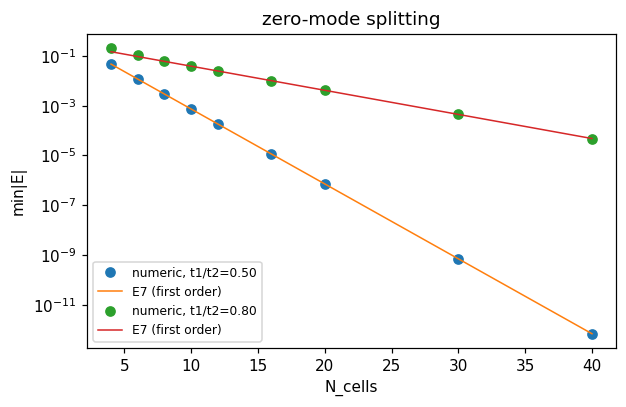

In [5]:
R = P["resolution"]; chain_rows = []; chain_data = {}
print("[영모드 분리 min|E|]   N_c : 수치 | E7(1차 섭동) | 수치/E7")
for (t1_, t2_) in R["ncell_pairs"]:
    r_ = t1_ / t2_; nums, ths = [], []
    for nc in R["ncell_list"]:
        num = float(np.min(np.abs(np.linalg.eigvalsh(finite_ssh(nc, t1_, t2_)))))
        th = t1_ * (1 - r_**2) * r_ ** (nc - 1)
        nums.append(num); ths.append(th); chain_rows.append([t1_, t2_, nc, num, th, num / th])
    chain_data[(t1_, t2_)] = (nums, ths)
    print(f"  (t1,t2)=({t1_},{t2_})")
    for nc, num, th in zip(R["ncell_list"], nums, ths):
        print(f"     N_c={nc:3d}: {num:.3e} | {th:.3e} | {num/th:.4f}")
    sel = np.array(R["ncell_list"]) >= R["fit_min_ncell"]
    slope = float(np.polyfit(np.array(R["ncell_list"])[sel], np.log(np.array(nums)[sel]), 1)[0])
    print(f"     d ln(min|E|)/dN_c = {slope:.3f}  (N_c >= {R['fit_min_ncell']} 에서 피팅) | 이론 ln r = {np.log(r_):.3f}")
    SUMMARY[f"zero_mode_t1={t1_},t2={t2_}"] = {"fit_slope": slope, "ln_r": float(np.log(r_))}
save_csv("zero_mode_splitting.csv", ["t1", "t2", "N_cells", "min_abs_E", "E7_first_order", "ratio"], chain_rows)

plt.figure(figsize=(5.8, 3.8))
for (t1_, t2_), (nums, ths) in chain_data.items():
    plt.semilogy(R["ncell_list"], nums, "o", label=f"numeric, t1/t2={t1_/t2_:.2f}")
    plt.semilogy(R["ncell_list"], ths, "-", lw=1, label="E7 (first order)")
plt.xlabel("N_cells"); plt.ylabel("min|E|"); plt.title("zero-mode splitting"); plt.legend(fontsize=8)
plt.tight_layout(); save_fig("fig8b_zero_mode_splitting"); plt.show()

**확인**: $(0.5,1)$에서 $N_c=10,20,40$일 때 수치 $7.32\times10^{-4},\ 7.15\times10^{-7},\ 6.82\times10^{-13}$이 E7과 같은 값이다(수치/E7 $=1.000$). $r=0.8$은 $N_c=10$에서 3.8 %, $N_c=20$에서 0.1 % 차이이고 $N_c=40$에서 일치한다 (1차 섭동은 $r$가 1에 가까울수록 더 긴 사슬이 필요하다). $\ln\min\lvert E\rvert$의 기울기는 $\ln r$와 일치한다($-0.693$, $-0.224$).

**한계**: E7은 벌크 상태와의 섞임(더 높은 차수)을 무시한 1차 어림이다. 무질서가 큰 경우에는 그대로 쓰지 않는다.

## 4. 카이랄 대칭 (이론 E8, 선형대수)

사이트를 A와 B로 나누면 $H=\begin{pmatrix}0&T^\dagger\\T&0\end{pmatrix}$이다. A에는 $+1$, B에는 $-1$을 곱하는 대각 행렬 $\Sigma$에 대해 $\Sigma H\Sigma=-H$이면 고유값이 $\pm E$ 쌍으로 나온다.

- hopping 무질서: 행렬에서 A–B 블록 $T$만 바뀐다 → 대칭 **유지**
- 온사이트 무질서: 대각 성분이 생긴다 → 대칭 **깨짐**

**예측**: $\lVert\Sigma H\Sigma+H\rVert$와 고유값 쌍의 어긋남 $\max_i\lvert E_i+E_{N-1-i}\rvert$는 두 무질서에서 어떻게 다른가?

In [6]:
CH = P["chiral"]; Dc = P["disorder"]; rng_c = np.random.default_rng(CH["seed"])

def rand_chain(n_cells, t1, t2, w_hop, v_site, rng):
    n = 2 * n_cells; H = np.zeros((n, n))
    for c in range(n_cells):
        t = t1 * (1 + w_hop * rng.uniform(-1, 1)); H[2*c, 2*c+1] = H[2*c+1, 2*c] = t
    for c in range(n_cells - 1):
        t = t2 * (1 + w_hop * rng.uniform(-1, 1)); H[2*c+1, 2*c+2] = H[2*c+2, 2*c+1] = t
    H += np.diag(v_site * rng.uniform(-1, 1, n))
    return H

Sigma = np.diag([1.0, -1.0] * Dc["n_cells"]); s_ = CH["strength"]; M_ = CH["n_realizations"]
chiral_rows = []
print(f"세기 s={s_}, 실현 {M_}개, 사슬 ({Dc['t1']}, {Dc['t2']}), 셀 {Dc['n_cells']}개")
print(f"{'무질서':>10} | {'||Sigma H Sigma + H|| 평균':>26} | {'max|E_i + E_(N-1-i)| 평균':>26}")
for label, (w, v) in {"hopping": (s_, 0.0), "onsite": (0.0, s_)}.items():
    norms, mism = [], []
    for _ in range(M_):
        H = rand_chain(Dc["n_cells"], Dc["t1"], Dc["t2"], w, v, rng_c)
        norms.append(np.linalg.norm(Sigma @ H @ Sigma + H))
        E = np.sort(np.linalg.eigvalsh(H)); mism.append(np.max(np.abs(E + E[::-1])))
    chiral_rows.append([label, float(np.mean(norms)), float(np.mean(mism))])
    print(f"{label:>10} | {np.mean(norms):26.2e} | {np.mean(mism):26.2e}")
save_csv("chiral_check.csv", ["disorder", "mean_norm_SHS_plus_H", "mean_pair_mismatch"], chiral_rows)
SUMMARY["chiral_check"] = {r[0]: {"norm": r[1], "pair_mismatch": r[2]} for r in chiral_rows}
Ec = np.linalg.eigvalsh(finite_ssh(Dc["n_cells"], Dc["t1"], Dc["t2"]))
print("깨끗한 사슬의 영 근처 두 에너지:", np.sort(Ec[np.argsort(np.abs(Ec))[:2]]))

세기 s=0.3, 실현 40개, 사슬 (0.5, 1.0), 셀 20개
       무질서 |   ||Sigma H Sigma + H|| 평균 |    max|E_i + E_(N-1-i)| 평균
   hopping |                   0.00e+00 |                   2.18e-15
    onsite |                   2.17e+00 |                   1.64e-01
깨끗한 사슬의 영 근처 두 에너지: [-7.15255738e-07  7.15255737e-07]


**확인**: hopping 무질서에서는 $\lVert\Sigma H\Sigma+H\rVert$가 정확히 0이고 고유값 쌍의 어긋남이 $\sim10^{-15}$(기계 정밀도)다. 온사이트 무질서에서는 각각 약 2.2와 약 0.16으로 대칭이 깨진다. 깨끗한 사슬에서는 두 영모드가 $\pm7.15\times10^{-7}$의 쌍으로 나온다.

**의미**: 대칭이 있으면 고유값이 $E=0$을 중심으로 쌍을 이루므로 두 끝 상태는 함께 같은 방향으로 밀리지 못한다. 대칭이 깨지면 함께 위나 아래로 이동할 수 있다. 엄밀한 보호 정리(지수 정리)는 인용한다.

## 5. 무질서 실험과 샘플링 (이론 E10)

비자명 사슬($t_1=0.5$, $t_2=1$, 셀 20개)에 같은 세기 $s$의 두 무질서를 준다: hopping $t\to t(1+s\,r)$, 온사이트 $\epsilon\in[-s,s]$ ($r$은 $[-1,1]$ 균등). 보는 양은 $x=\log_{10}\min\lvert E\rvert$, 실현 $M$개의 평균 ± 표준오차 $\mathrm{SE}=\sigma/\sqrt M$. 난수 시드는 입력 파일에 고정되어 있다.

**예측**: 어느 무질서에서 영모드가 $E=0$ 근처에 남는가? $M$을 늘리면 SE는?

    s |     hopping: mean ± SE |      onsite: mean ± SE   (x = log10 min|E|, M=40)
 0.00 |   -6.146 ± 0.000      |   -6.146 ± 0.000
 0.10 |   -6.193 ± 0.024      |   -1.742 ± 0.064
 0.20 |   -6.109 ± 0.051      |   -1.415 ± 0.067
 0.30 |   -6.249 ± 0.078      |   -1.399 ± 0.082
 0.40 |   -6.106 ± 0.098      |   -1.232 ± 0.094

표본 수 M 에 따른 SE (s=0.3):  M | SE(hopping) | SE(onsite) | sigma/sqrt(M) 이론선 기준
  M=   5 | 0.111 | 0.213
  M=  10 | 0.160 | 0.146
  M=  20 | 0.096 | 0.084
  M=  40 | 0.072 | 0.058
  M=  80 | 0.045 | 0.046
  M= 160 | 0.034 | 0.040


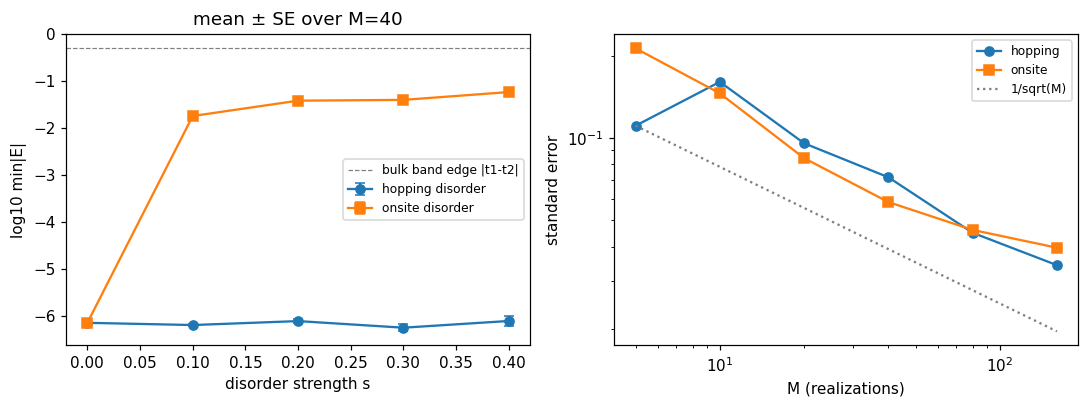

In [7]:
D = P["disorder"]
rng = np.random.default_rng(D["seed"])

def finite_ssh_random(n_cells, t1, t2, w_hop, v_site, rng):
    n = 2 * n_cells; H = np.zeros((n, n))
    for c in range(n_cells):
        t = t1 * (1 + w_hop * rng.uniform(-1, 1)); H[2*c, 2*c+1] = H[2*c+1, 2*c] = t
    for c in range(n_cells - 1):
        t = t2 * (1 + w_hop * rng.uniform(-1, 1)); H[2*c+1, 2*c+2] = H[2*c+2, 2*c+1] = t
    H += np.diag(v_site * rng.uniform(-1, 1, n))
    return H

def sample_x(w_hop, v_site, M):
    xs = np.empty(M)
    for i in range(M):
        H = finite_ssh_random(D["n_cells"], D["t1"], D["t2"], w_hop, v_site, rng)
        xs[i] = np.log10(np.min(np.abs(np.linalg.eigvalsh(H))))
    return xs

M = D["n_realizations"]
rows, res = [], {"hopping": [], "onsite": []}
print(f"{'s':>5} | {'hopping: mean ± SE':>22} | {'onsite: mean ± SE':>22}   (x = log10 min|E|, M={M})")
for s in D["strengths"]:
    xh = sample_x(s, 0.0, M); xo = sample_x(0.0, s, M)
    for kind, xs in (("hopping", xh), ("onsite", xo)):
        mean, se = float(xs.mean()), float(xs.std(ddof=1) / np.sqrt(M))
        res[kind].append((s, mean, se)); rows.append([kind, s, M, mean, se])
    print(f"{s:5.2f} | {res['hopping'][-1][1]:+8.3f} ± {res['hopping'][-1][2]:.3f}      | {res['onsite'][-1][1]:+8.3f} ± {res['onsite'][-1][2]:.3f}")
save_csv("disorder.csv", ["type", "strength", "M", "mean_log10_minE", "standard_error"], rows)
SUMMARY["disorder"] = {k: [{"s": s, "mean": m_, "se": e_} for s, m_, e_ in v] for k, v in res.items()}

# 표본 수 M 에 따른 표준오차 (같은 세기 s = M_strength 에서 160개를 뽑아 앞의 M개만 사용)
sM = D["M_strength"]; Mmax = max(D["M_list"])
xh_all = sample_x(sM, 0.0, Mmax); xo_all = sample_x(0.0, sM, Mmax)
se_rows = []
print(f"\n표본 수 M 에 따른 SE (s={sM}):  M | SE(hopping) | SE(onsite) | sigma/sqrt(M) 이론선 기준")
for Mi in D["M_list"]:
    seh = xh_all[:Mi].std(ddof=1) / np.sqrt(Mi); seo = xo_all[:Mi].std(ddof=1) / np.sqrt(Mi)
    se_rows.append([Mi, float(seh), float(seo)])
    print(f"  M={Mi:4d} | {seh:.3f} | {seo:.3f}")
save_csv("disorder_M_dependence.csv", ["M", "SE_hopping", "SE_onsite"], se_rows)
SUMMARY["disorder_M_dependence"] = se_rows

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for kind, mk in (("hopping", "o"), ("onsite", "s")):
    s_ = [r[0] for r in res[kind]]; m_ = [r[1] for r in res[kind]]; e_ = [r[2] for r in res[kind]]
    ax[0].errorbar(s_, m_, yerr=e_, fmt=mk + "-", capsize=3, label=f"{kind} disorder")
ax[0].axhline(np.log10(abs(D["t1"] - D["t2"])), color="gray", ls="--", lw=0.8, label="bulk band edge |t1-t2|")
ax[0].set_xlabel("disorder strength s"); ax[0].set_ylabel("log10 min|E|"); ax[0].legend(fontsize=8); ax[0].set_title(f"mean ± SE over M={M}")
Ms = np.array([r[0] for r in se_rows]); ax[1].loglog(Ms, [r[1] for r in se_rows], "o-", label="hopping"); ax[1].loglog(Ms, [r[2] for r in se_rows], "s-", label="onsite")
ax[1].loglog(Ms, se_rows[0][1] * np.sqrt(Ms[0] / Ms), ":", color="gray", label="1/sqrt(M)")
ax[1].set_xlabel("M (realizations)"); ax[1].set_ylabel("standard error"); ax[1].legend(fontsize=8)
plt.tight_layout(); save_fig("fig9_disorder"); plt.show()

**확인**
- hopping(대칭 유지): $x\approx-6.1\sim-6.2$로 세기와 무관 ($s=0.4$에서 $-6.11\pm0.10$). 유한 길이 섞임 수준 $\sim10^{-6}$에 머문다
- 온사이트(대칭 깨짐): $x=-1.74\pm0.06$ ($s=0.1$) $\to-1.23\pm0.09$ ($s=0.4$), 즉 $\min\lvert E\rvert\approx0.02\sim0.06$. 갭 안에는 남지만 $E=0$에 고정되지 않는다
- 차이는 약 4~5 자릿수로 표준오차(0.1 이하)보다 훨씬 크다
- $M=5\to160$에서 SE는 hopping $0.111\to0.034$, 온사이트 $0.213\to0.040$으로 대략 $1/\sqrt M$로 준다 (작은 $M$에서는 SE 자체가 흔들린다)

## 6. 회전수 (E9)와 Zak phase (인용)

$h(k)=t_1+t_2e^{ik}$는 복소평면에서 중심 $t_1$, 반지름 $t_2$인 원이다. 원점을 감는 횟수가 회전수 $W$이고, 닫힌 곡선이라 정수다. 원점을 품으려면 $t_2>t_1$이다. $W$가 바뀌는 곳은 곡선이 원점을 지나는 $t_1=t_2$(갭이 닫힘)뿐이다.

**예측**: $(1,0.5),(0.5,1),(2,1),(1,3)$의 회전수는?

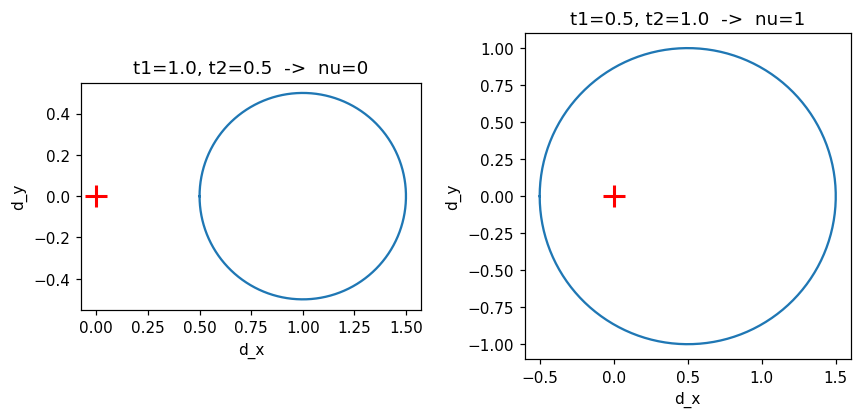

t1=1.0, t2=0.5  ->  nu = 0   (기대: 0)
t1=0.5, t2=1.0  ->  nu = 1   (기대: 1)
t1=2.0, t2=1.0  ->  nu = 0   (기대: 0)
t1=1.0, t2=3.0  ->  nu = 1   (기대: 1)


In [8]:
def winding_number(t1, t2, n_k=4000, k=None):
    if k is None:
        k = np.linspace(-np.pi, np.pi, n_k, endpoint=False)
    d = (t1 + t2 * np.cos(k)) + 1j * (t2 * np.sin(k))     # d_x + i d_y
    # 닫힌 곡선: 이웃한 점 사이의 각도 증분(-pi~pi)을 전부 더한다
    dtheta = np.angle(np.roll(d, -1) / d)
    return int(round(dtheta.sum() / (2 * np.pi)))

fig, ax = plt.subplots(1, len(pairs), figsize=(4 * len(pairs), 3.8))
kk = np.linspace(-np.pi, np.pi, 400)
for a_, (t1, t2) in zip(np.atleast_1d(ax), pairs):
    a_.plot(t1 + t2*np.cos(kk), t2*np.sin(kk))
    a_.plot(0, 0, "r+", ms=14, mew=2)
    a_.set_aspect("equal"); a_.set_xlabel("d_x"); a_.set_ylabel("d_y")
    a_.set_title(f"t1={t1}, t2={t2}  ->  nu={winding_number(t1, t2)}")
plt.tight_layout(); save_fig("fig5_dvec_compare"); plt.show()

wind_rows = []
for t1, t2 in P["winding_pairs"]:
    nu = winding_number(t1, t2); wind_rows.append((t1, t2, nu))
    print(f"t1={t1}, t2={t2}  ->  nu = {nu}   (기대: {1 if t2 > t1 else 0})")
    assert nu == (1 if t2 > t1 else 0)
SUMMARY["winding"] = {f"t1={a},t2={b}": nu for a, b, nu in wind_rows}

**Zak phase**: 이웃 $k$의 고유벡터 겹침을 곱해 위상을 읽는다. $\gamma=\pi W\ (\mathrm{mod}\ 2\pi)$ 관계는 **이론에서 인용**하고 여기서는 계산만 한다. 부호는 규약(위상 방향, 단위셀 원점)에 따라 달라서 크기만 본다.

  t1   t2 |  |Zak|/pi | winding nu
 1.0  0.5 |    0.0000 |          0
 0.5  1.0 |    1.0000 |          1
 2.0  1.0 |    0.0000 |          0
 1.0  3.0 |    1.0000 |          1
스캔한 t2 개수: 39
|Zak|/pi 가 0 또는 1 에서 벗어난 최대량: 4.440892098500626e-16
t2 < t1 인 점에서의 값 범위: 2.216395184445615e-18 ~ 2.55686410476816e-16
t2 > t1 인 점에서의 값 범위: 0.9999999999999996 ~ 1.0


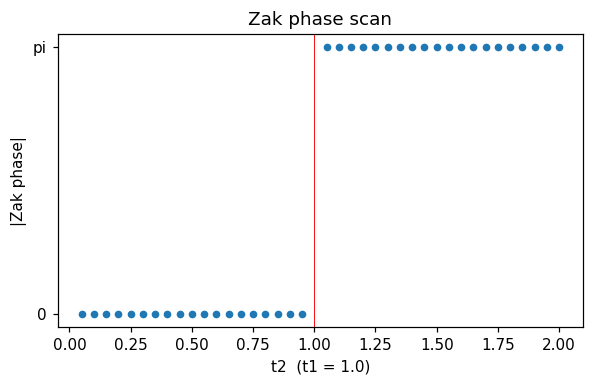

In [9]:
def zak_phase(t1, t2, n_k=400, k=None):
    if k is None:
        k = np.linspace(-np.pi, np.pi, n_k, endpoint=False)
    off = t1 + t2 * np.exp(1j * k)
    H = np.zeros((len(k), 2, 2), dtype=complex); H[:, 0, 1] = off; H[:, 1, 0] = np.conj(off)
    _, V = np.linalg.eigh(H); u = V[:, :, 0]                 # 아래 밴드 고유벡터 (각 k 마다)
    ov = np.sum(np.conj(u) * np.roll(u, -1, axis=0), axis=1) # <u_j | u_{j+1}> (닫힌 고리: 마지막은 처음과 연결)
    return -np.angle(np.prod(ov))

print(f"{'t1':>4} {'t2':>4} | {'|Zak|/pi':>9} | {'winding nu':>10}")
zak_tab = {}
for t1, t2 in P["winding_pairs"]:
    gz = zak_phase(t1, t2, P["zak_k_points"])
    zak_tab[f"t1={t1},t2={t2}"] = abs(gz) / np.pi
    print(f"{t1:4.1f} {t2:4.1f} | {abs(gz)/np.pi:9.4f} | {winding_number(t1, t2):10d}")
SUMMARY["zak_over_pi"] = zak_tab

# t2 스캔: Zak phase 가 0 또는 pi 로 양자화되고 t2 = t1 에서 뛰는지 확인
zs = P["zak_scan"]
t2_scan = np.linspace(zs["t2_min"], zs["t2_max"], zs["n"])
t2_scan = t2_scan[np.abs(t2_scan - zs["t1"]) > 1e-9]       # 갭이 닫히는 t2 = t1 은 제외 (위상수가 정의되지 않음)
zak_scan = np.array([abs(zak_phase(zs["t1"], t2, P["zak_k_points"])) / np.pi for t2 in t2_scan])
w_scan = np.array([winding_number(zs["t1"], t2) for t2 in t2_scan])
dev = float(np.max(np.minimum(zak_scan, np.abs(zak_scan - 1))))
print("스캔한 t2 개수:", len(t2_scan))
print("|Zak|/pi 가 0 또는 1 에서 벗어난 최대량:", dev)
print("t2 < t1 인 점에서의 값 범위:", zak_scan[t2_scan < zs["t1"]].min(), "~", zak_scan[t2_scan < zs["t1"]].max())
print("t2 > t1 인 점에서의 값 범위:", zak_scan[t2_scan > zs["t1"]].min(), "~", zak_scan[t2_scan > zs["t1"]].max())
SUMMARY["zak_scan_quantization_dev"] = dev
save_csv("zak_scan.csv", ["t2", "abs_zak_over_pi", "winding"], zip(t2_scan.tolist(), zak_scan.tolist(), w_scan.tolist()))

plt.figure(figsize=(5.5, 3.6))
plt.plot(t2_scan, zak_scan, "o", ms=4)
plt.axvline(zs["t1"], color="r", lw=0.6)
plt.yticks([0, 1], ["0", "pi"]); plt.xlabel(f"t2  (t1 = {zs['t1']})"); plt.ylabel("|Zak phase|")
plt.title("Zak phase scan"); plt.tight_layout(); save_fig("fig_zak_scan"); plt.show()

**확인**: 회전수는 $0,1,0,1$이고 $\lvert\gamma\rvert/\pi$도 같은 값이다. $t_2$를 스캔하면 $t_2<t_1$에서 0, $t_2>t_1$에서 $\pi$이고 바뀌는 곳은 $t_2=t_1$ 한 점이다 (벗어남 $<10^{-15}$). 회전수 1인 사슬에서만 갭 안 상태가 있는 것은 1~2절에서 확인한 조건 $t_2>t_1$과 정확히 같다. 일반적인 이유(벌크–경계 대응)는 인용한다.

## 7. 검증 요약, 해석, 한계

| 점검 | 증거 | 결과 |
|---|---|---|
| 기준 비교 | 진폭비, 감쇠율, 첫 사이트 확률의 해석값 / $t_1\to0$ 극한 / $r\to1$에서 $\xi$ 발산 | 일치 (2절) |
| 수치 해상도 | 사슬 길이에 따른 영모드 분리 vs 1차 섭동 E7 | 일치, 기울기 $\ln r$ (3절) |
| 샘플링 | 난수 무질서 $M=40$, 평균 ± 표준오차, $M$ 의존성 | hopping: $E=0$ 유지, 온사이트: 이탈 (5절) |
| 해석 | 카이랄 대칭(선형대수), 회전수 | 4절, 6절 |

**물리적 의미**: 갭 안의 상태는 사슬 끝에 국소화된 한 부격자 한정 상태이고, $t_2>t_1$일 때만 존재하며(진폭의 규격화), 사슬이 길수록 $E=0$에 지수적으로 가까워진다. 카이랄 대칭을 지키는 무질서에서는 $E=0$ 근처에 남고, 깨는 무질서에서는 $E=0$에서 떨어진다.

**확인하지 않은 것과 확인 방법**
| 확인하지 않은 것 | 어떻게 확인할 것인가 |
|---|---|
| 큰 무질서($s>0.4$)에서 벌크 갭이 닫힐 때 | 세기를 키우며 벌크 갭과 $\min\lvert E\rvert$를 함께 추적 |
| 사슬 길이 20셀, 균등분포만 | 더 긴 사슬, 다른 분포로 반복 |
| 실제 물질(폴리아세틸렌)의 $t_1,t_2$ | 문헌의 hopping 값으로 같은 계산 반복 |
| 보호의 엄밀한 정리, 벌크–경계 대응의 일반 증명 | 이론에서 인용 (이 프로젝트는 수치 확인까지) |
| 2차원(그래핀), 전자 사이의 상호작용 | 이 모델의 범위 밖 |

**규약 주의**: 유한 사슬이 A 원자에서 시작하고 첫 결합이 $t_1$이라는 규약을 쓴다. 이 규약을 바꾸면 갭 안 상태가 생기는 사슬이 뒤바뀐다.

## 출력 파일 저장

In [10]:
with open(OUT / "summary.json", "w") as f:
    json.dump(SUMMARY, f, indent=2, ensure_ascii=False, default=float)
print("저장된 출력 파일:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(" ", p.as_posix(), f"({p.stat().st_size} bytes)")

저장된 출력 파일:
  output/chiral_check.csv (133 bytes)
  output/disorder.csv (563 bytes)
  output/disorder_M_dependence.csv (287 bytes)
  output/edge_amplitude.csv (337 bytes)
  output/edge_density.csv (1899 bytes)
  output/edge_states.csv (1748 bytes)
  output/figs/fig5_dvec_compare.png (63976 bytes)
  output/figs/fig6_edge_states.png (56080 bytes)
  output/figs/fig7_edge_decay.png (32388 bytes)
  output/figs/fig8b_zero_mode_splitting.png (50186 bytes)
  output/figs/fig9_disorder.png (83438 bytes)
  output/figs/fig_zak_scan.png (18279 bytes)
  output/localization.csv (630 bytes)
  output/summary.json (3733 bytes)
  output/zak_scan.csv (1139 bytes)
  output/zero_mode_splitting.csv (1298 bytes)
